# AEGES-Q: Quantum Machine Learning Experiments

This notebook is the experimental workspace for the quantum machine learning component of AEGES-Q.

The purpose is to:

1. Understand basic quantum operations.
2. Encode classical network features into quantum states.
3. Experiment with different quantum circuits.
4. Develop a trainable quantum machine learning model.
5. Compare quantum and classical classification performance.
6. Select the most suitable circuit for integration into AEGES-Q.

The existing classical machine learning pipeline will be treated as the baseline.

In [3]:
# installing libraries 
%pip install -q qiskit qiskit-aer qiskit-machine-learning numpy pandas matplotlib scikit-learn pylatexenc

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Environment Verification

This section verifies that the quantum computing libraries are available inside the current notebook environment.

The experiments use:

- Qiskit for quantum circuit construction
- Qiskit Aer for local quantum simulation
- Qiskit Machine Learning for trainable quantum models
- NumPy for numerical operations
- Pandas for tabular data
- Matplotlib for visualizations

All initial experiments will run on a local simulator.

In [4]:
import sys
from importlib.metadata import version

import qiskit
import qiskit_aer


print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

print("\nQiskit version:")
print(qiskit.__version__)

print("\nQiskit Aer version:")
print(qiskit_aer.__version__)

print("\nQiskit Machine Learning version:")
print(version("qiskit-machine-learning"))

Python executable:
c:\Users\Askari\AppData\Local\Programs\Python\Python313\python.exe

Python version:
3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]

Qiskit version:
2.5.2

Qiskit Aer version:
0.17.2

Qiskit Machine Learning version:
0.9.1


In [5]:
from qiskit_aer import AerSimulator

simulator = AerSimulator()

print("Aer simulator initialized successfully.")

Aer simulator initialized successfully.


## 2. Quantum Computing Refresher

A classical bit can contain either 0 or 1.

A qubit also produces either 0 or 1 when measured. Before measurement, however, it can exist in a superposition of both states:

\[
|\psi\rangle = \alpha|0\rangle + \beta|1\rangle
\]

where:

\[
|\alpha|^2 + |\beta|^2 = 1
\]

The values of \(\alpha\) and \(\beta\) determine the probabilities of measuring 0 or 1.

Quantum gates modify these probabilities.

The `RY` gate rotates a qubit according to an input angle. This makes it useful for converting classical numerical features into quantum states.

## 3. Experiment 1 — Single-Qubit Rotation

This experiment demonstrates how changing a rotation angle changes the probability of measuring a qubit as 0 or 1.

The circuit contains:

1. One qubit
2. An `RY` rotation gate
3. A measurement operation

Expected behavior:

- Angle 0: almost always 0
- Angle π/4: mostly 0, with some 1 outcomes
- Angle π/2: approximately equal probabilities
- Angle π: almost always 1

In [6]:
# single qubit circuit experiment 
from math import pi

from qiskit import QuantumCircuit

angles = [
    0,
    pi / 4,
    pi / 2,
    pi,
]

rotation_results = {}

for angle in angles:
    circuit = QuantumCircuit(1, 1)

    # Rotate qubit 0 around the Y axis
    circuit.ry(angle, 0)

    # Measure qubit 0 into classical bit 0
    circuit.measure(0, 0)

    result = simulator.run(
        circuit,
        shots=1000,
    ).result()

    counts = result.get_counts()
    rotation_results[angle] = counts

    print(f"Angle: {angle:.4f}")
    print("Counts:", counts)
    print("-" * 30)

Angle: 0.0000
Counts: {'0': 1000}
------------------------------
Angle: 0.7854
Counts: {'0': 846, '1': 154}
------------------------------
Angle: 1.5708
Counts: {'1': 495, '0': 505}
------------------------------
Angle: 3.1416
Counts: {'1': 1000}
------------------------------


### Interpretation

The probability of measuring 1 after an `RY` rotation is:

\[
P(1) = \sin^2\left(\frac{\theta}{2}\right)
\]

Therefore, changing the rotation angle changes the measurement probability.

This is the basic principle of quantum feature encoding.

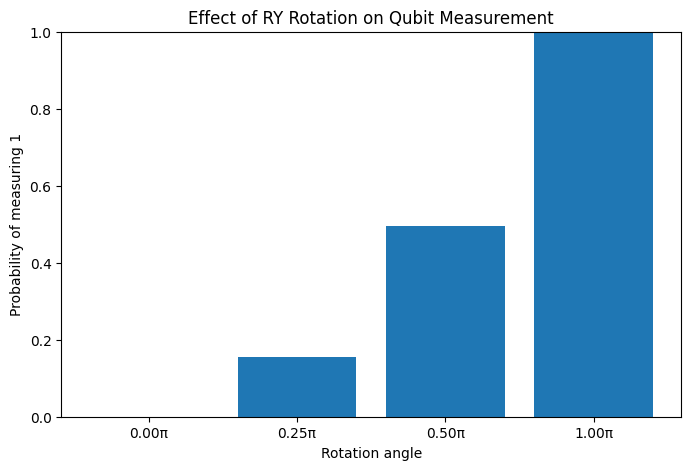

In [7]:
import matplotlib.pyplot as plt

angle_labels = []
probability_of_one = []

for angle, counts in rotation_results.items():
    total_shots = sum(counts.values())
    ones = counts.get("1", 0)

    angle_labels.append(f"{angle / pi:.2f}π")
    probability_of_one.append(ones / total_shots)

plt.figure(figsize=(8, 5))
plt.bar(angle_labels, probability_of_one)

plt.xlabel("Rotation angle")
plt.ylabel("Probability of measuring 1")
plt.title("Effect of RY Rotation on Qubit Measurement")
plt.ylim(0, 1)

plt.show()

## 4. Experiment 2 — Two-Qubit Entanglement

This experiment demonstrates quantum entanglement.

The circuit uses:

1. A Hadamard gate on the first qubit
2. A controlled-NOT gate between the two qubits
3. Measurement of both qubits

The expected results are correlated outcomes:

- 00
- 11

The outcomes 01 and 10 should ideally not occur.

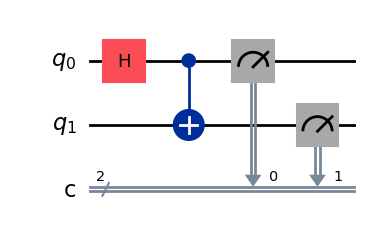

In [8]:
from qiskit import QuantumCircuit

entanglement_circuit = QuantumCircuit(2, 2)

# Create superposition on qubit 0
entanglement_circuit.h(0)

# Entangle qubit 1 with qubit 0
entanglement_circuit.cx(0, 1)

# Measure both qubits
entanglement_circuit.measure([0, 1], [0, 1])

entanglement_circuit.draw("mpl")

In [9]:
entanglement_result = simulator.run(
    entanglement_circuit,
    shots=1000,
).result()

entanglement_counts = entanglement_result.get_counts()

print(entanglement_counts)

{'11': 502, '00': 498}


### Interpretation

The Hadamard gate creates a superposition on the first qubit.

The CNOT gate creates a relationship between the two qubits.

As a result, the measurements are correlated.

This demonstrates how quantum circuits can represent relationships between variables.

## 5. Experiment 3 — Classical Feature Encoding

A quantum circuit cannot directly receive a raw network feature such as:

- Packet length
- Source bytes
- Destination bytes
- Connection duration

The classical feature must first be converted into a numerical angle.

For this experiment, each feature is normalized to the range:

\[
[0, 1]
\]

The normalized value is then converted into an angle:

\[
\theta = x\pi
\]

where:

- \(x\) is the normalized feature value
- \(\theta\) is the quantum rotation angle

The angle is applied using an `RY` gate.

In [10]:
import numpy as np

sample_features = np.array([
    0.0,
    0.25,
    0.5,
    0.75,
    1.0,
])

encoded_angles = sample_features * np.pi

print("Feature values:")
print(sample_features)

print("\nEncoded angles:")
print(encoded_angles)

Feature values:
[0.   0.25 0.5  0.75 1.  ]

Encoded angles:
[0.         0.78539816 1.57079633 2.35619449 3.14159265]


In [11]:
def create_feature_encoding_circuit(feature_values):
    """
    Encode normalized feature values into qubit rotations.

    Each feature must be in the range [0, 1].
    Each feature is encoded into one qubit using an RY gate.
    """

    feature_values = np.asarray(feature_values, dtype=float)

    if np.any(feature_values < 0) or np.any(feature_values > 1):
        raise ValueError("All feature values must be between 0 and 1.")

    number_of_features = len(feature_values)

    circuit = QuantumCircuit(
        number_of_features,
        number_of_features,
    )

    for qubit_index, feature_value in enumerate(feature_values):
        angle = feature_value * np.pi
        circuit.ry(angle, qubit_index)

    circuit.measure(
        range(number_of_features),
        range(number_of_features),
    )

    return circuit

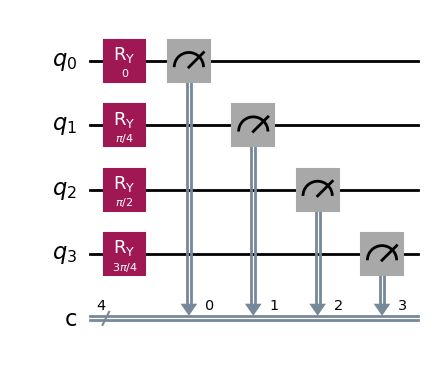

In [12]:
sample_circuit = create_feature_encoding_circuit(
    [0.0, 0.25, 0.5, 0.75]
)

sample_circuit.draw("mpl")

In [13]:
sample_result = simulator.run(
    sample_circuit,
    shots=1000,
).result()

sample_counts = sample_result.get_counts()

print(sample_counts)

{'0000': 71, '1000': 401, '1100': 337, '1110': 56, '0100': 60, '1010': 58, '0110': 8, '0010': 9}


### Interpretation

Each classical feature controls the rotation of one qubit.

For example:

- Feature value 0 produces an angle of 0
- Feature value 0.5 produces an angle of π/2
- Feature value 1 produces an angle of π

The measurement probabilities contain information about the original feature values.

This is the first step toward using quantum circuits for network traffic classification.

## 6. Experiment 4 — Variational Quantum Circuit

A variational quantum circuit contains trainable parameters.

The circuit has two types of values:

### Input features

These represent the network traffic features.

### Trainable parameters

These are adjusted during training to improve classification performance.

The general structure is:

1. Encode input features.
2. Apply trainable rotation gates.
3. Create relationships between qubits.
4. Measure the circuit.
5. Convert the measurement into a prediction.

The trainable parameters are optimized using a classical optimizer.

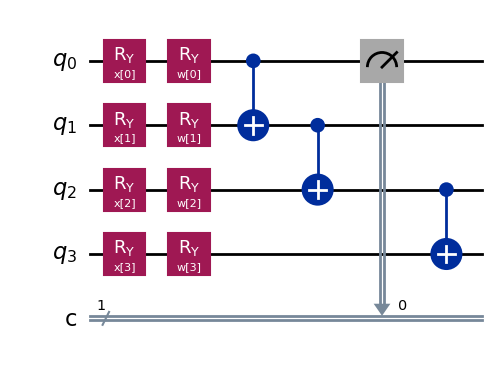

In [14]:
from qiskit.circuit import ParameterVector

number_of_qubits = 4

input_parameters = ParameterVector(
    "x",
    length=number_of_qubits,
)

trainable_parameters = ParameterVector(
    "w",
    length=number_of_qubits,
)

variational_circuit = QuantumCircuit(
    number_of_qubits,
    1,
)

# Encode input features
for index in range(number_of_qubits):
    variational_circuit.ry(
        input_parameters[index],
        index,
    )

# Apply trainable parameters
for index in range(number_of_qubits):
    variational_circuit.ry(
        trainable_parameters[index],
        index,
    )

# Create interactions between neighboring qubits
for index in range(number_of_qubits - 1):
    variational_circuit.cx(
        index,
        index + 1,
    )

# Measure the first qubit
variational_circuit.measure(0, 0)

variational_circuit.draw("mpl")

### Circuit Explanation

The first group of `RY` gates encodes the input features.

The second group of `RY` gates contains trainable parameters.

The CNOT gates create interactions between neighboring qubits.

The first qubit is measured to produce the initial model output.

The probability of measuring 1 can be interpreted as the output of the quantum model.

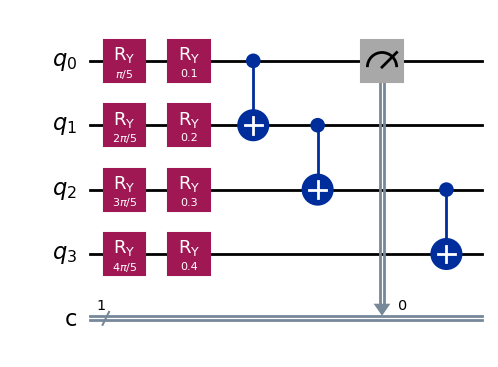

In [15]:
sample_feature_values = {
    input_parameters[0]: 0.2 * np.pi,
    input_parameters[1]: 0.4 * np.pi,
    input_parameters[2]: 0.6 * np.pi,
    input_parameters[3]: 0.8 * np.pi,
}

sample_trainable_values = {
    trainable_parameters[0]: 0.1,
    trainable_parameters[1]: 0.2,
    trainable_parameters[2]: 0.3,
    trainable_parameters[3]: 0.4,
}

parameter_values = {
    **sample_feature_values,
    **sample_trainable_values,
}

bound_circuit = variational_circuit.assign_parameters(
    parameter_values,
)

bound_circuit.draw("mpl")

In [16]:
bound_result = simulator.run(
    bound_circuit,
    shots=1000,
).result()

bound_counts = bound_result.get_counts()

print(bound_counts)

{'0': 863, '1': 137}


In [17]:
bound_result = simulator.run(
    bound_circuit,
    shots=1000,
).result()

bound_counts = bound_result.get_counts()

print(bound_counts)

{'0': 866, '1': 134}


In [18]:
total_shots = sum(bound_counts.values())
probability_of_attack = bound_counts.get("1", 0) / total_shots

print("Probability of measuring 1:", probability_of_attack)

Probability of measuring 1: 0.134


## 7. Experiment Comparison

The candidate circuits will be compared using:

| Criterion | Description |
|---|---|
| Circuit depth | Number of sequential quantum operations |
| Number of qubits | Quantum resources required |
| Feature capacity | Number of input features encoded |
| Trainability | Ability to optimize circuit parameters |
| Measurement output | Whether the circuit produces a useful prediction |
| Simulation cost | Time and computational resources required |
| Classification performance | Accuracy, precision, recall, F1-score, and ROC-AUC |

The best circuit will not necessarily be the deepest circuit.

The selected circuit should balance classification performance, computational cost, and implementation complexity.

In [19]:
import pandas as pd

experiment_comparison = [
    {
        "experiment": "Single-qubit rotation",
        "qubits": 1,
        "trainable": False,
        "purpose": "Understand quantum feature encoding",
    },
    {
        "experiment": "Two-qubit entanglement",
        "qubits": 2,
        "trainable": False,
        "purpose": "Understand relationships between qubits",
    },
    {
        "experiment": "Feature encoding circuit",
        "qubits": 4,
        "trainable": False,
        "purpose": "Encode multiple classical features",
    },
    {
        "experiment": "Variational circuit",
        "qubits": 4,
        "trainable": True,
        "purpose": "Prepare a QML classification model",
    },
]

experiment_comparison_df = pd.DataFrame(
    experiment_comparison
)

experiment_comparison_df

,experiment,qubits,trainable,purpose
0,Single-qubit rotation,1,False,Understand quantum feature encoding
1,Two-qubit entanglement,2,False,Understand relationships between qubits
2,Feature encoding circuit,4,False,Encode multiple classical features
3,Variational circuit,4,True,Prepare a QML classification model


## 8. Best Circuit Selection

The final circuit will be selected after testing candidate models on the same dataset split used for the classical baseline.

The selection will consider:

1. F1-score
2. Recall
3. ROC-AUC
4. False-positive rate
5. Training time
6. Inference time
7. Circuit depth
8. Number of qubits

The selected circuit will then be considered for integration into the AEGES-Q framework.

## 9. Next Steps for AEGES-Q

The next implementation stages are:

1. Select a manageable subset of UNSW-NB15 features.
2. Normalize the selected features.
3. Encode the features into a quantum circuit.
4. Build a trainable variational quantum classifier.
5. Train the model using the training split.
6. Evaluate it using the same test split as the classical model.
7. Compare the quantum and classical results.
8. Select the best-performing circuit.
9. Integrate the selected quantum model into the AEGES-Q backend.
10. Use the predicted threat severity to select an appropriate cryptographic policy.